 # Environnement & imports

In [3]:
# ============================================================
# CELLULE 1 — Environnement & imports
# ============================================================
import os, math, time, csv
from pathlib import Path
from collections import defaultdict
!pip install codecarbon
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import (resnet18, resnet50,
                                 ResNet18_Weights, ResNet50_Weights,
                                 efficientnet_b0, EfficientNet_B0_Weights)
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              f1_score, precision_score, recall_score)
import yaml

# — Hardware —
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device           : {DEVICE}")
print(f"GPUs disponibles : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i} : {torch.cuda.get_device_name(i)} "
          f"— {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")
print(f"PyTorch          : {torch.__version__}")

Device           : cuda
GPUs disponibles : 2
  GPU 0 : Tesla T4 — 15.6 GB
  GPU 1 : Tesla T4 — 15.6 GB
PyTorch          : 2.10.0+cu128


# Config YAML générique

In [4]:
# ============================================================
# CELLULE 2 — Config YAML générique
# Changer arch: 'resnet18' | 'resnet50' | 'efficientnet_b0'
# ============================================================
import yaml

BASELINE_CONFIG = """
# optimisation
n_epoch: 50
B: 16
n_epoch_warmup: 10
lr: 0.0001
wd: 0.1

# dataset
n_class: 2
data_dir: '/kaggle/input/datasets/pshikk/node-21-dataset-untampered'
n_worker: 4
pin_memory: True
eager: True

# divers
eps: 0.000001
seed: 0
track_epochs: [0, 1]

# encodeur
n_chan_in: 1           # grayscale
pretrained: True
img_size:  1024           # résolution d'entrée commune aux 3 archs

# ← SEUL PARAMÈTRE À CHANGER ENTRE LES 3 NOTEBOOKS
arch: 'resnet18'       # 'resnet18' | 'resnet50' | 'efficientnet_b0'

# tâches
tasks:
  task0:
    id: 0
    name: 'nodule'
    act_fn: 'softmax'
    metric:
      - accuracy
      - auc
      - f1
      - precision
      - recall
"""

class Struct:
    def __init__(self, **entries):
        self.__dict__.update(entries)

conf = Struct(**yaml.safe_load(BASELINE_CONFIG))

# — Vérification —
print(f"Architecture : {conf.arch}")
print(f"Pretrained   : {conf.pretrained}")
print(f"img_size     : {conf.img_size}")
print(f"n_epoch      : {conf.n_epoch}")
print(f"Tasks        : {[t['name'] for t in conf.tasks.values()]}")

Architecture : resnet50
Pretrained   : True
img_size     : 224
n_epoch      : 1
Tasks        : ['nodule']


# Config YAML DDR Baseline

In [5]:
# ============================================================
# CELLULE 2 — Config YAML DDR Baseline
# Adapté depuis ddr_conf (notebook IPS) pour BaselineNet :
#   - suppression des paramètres IPS (N, M, I, patch_size, etc.)
#   - suppression des paramètres agrégateur (H, D, D_k, etc.)
#   - ajout de img_size (224) pour BaselineNet
#   - arch : 'resnet18' | 'resnet50' | 'efficientnet_b0'
# ============================================================
import yaml

DDR_BASELINE_CONFIG = """
# optimisation
n_epoch: 50
B: 16
n_epoch_warmup: 10
lr: 0.0001
wd: 0.1

# dataset
n_class: 5
data_dir: '/kaggle/input/datasets/samriddhibagchi/ddr-dataset-credits-to-authors/DDR-dataset'
n_worker: 4
pin_memory: True
eager: True

# divers
eps: 0.000001
seed: 42
track_epochs: [0, 1]

# encodeur
n_chan_in: 3           # RGB
pretrained: True
img_size: 896          # résolution commune aux 3 archs

# ← SEUL PARAMÈTRE À CHANGER ENTRE LES 3 RUNS
arch: 'resnet18'       # 'resnet18' | 'resnet50' | 'efficientnet_b0'

# tâches
tasks:
  task0:
    id: 0
    name: 'dr_grade'
    act_fn: 'softmax'
    metric:
      - accuracy
      - kappa
      - f1
"""

class Struct:
    def __init__(self, **entries):
        self.__dict__.update(entries)

ddr_conf = Struct(**yaml.safe_load(DDR_BASELINE_CONFIG))

# — Vérification —
print(f"Architecture : {ddr_conf.arch}")
print(f"Dataset      : {ddr_conf.data_dir}")
print(f"n_class      : {ddr_conf.n_class}")
print(f"img_size     : {ddr_conf.img_size}")
print(f"Tasks        : {[t['name'] for t in ddr_conf.tasks.values()]}")
print(f"Métriques    : {ddr_conf.tasks['task0']['metric']}")

Architecture : resnet18
Dataset      : /kaggle/input/datasets/samriddhibagchi/ddr-dataset-credits-to-authors/DDR-dataset
n_class      : 5
img_size     : 896
Tasks        : ['dr_grade']
Métriques    : ['accuracy', 'kappa', 'f1']


# Config YAML RSNA Baseline.

In [19]:
# ============================================================
# STEP 1 — Config YAML RSNA Baseline
# Classification binaire : Pneumonia (1) vs No Pneumonia (0)
# Aligné Han et al. 2022 : split 75/25
# arch : 'resnet18' | 'resnet50' | 'efficientnet_b0'
# ============================================================
import yaml

RSNA_BASELINE_CONFIG = """
# optimisation
n_epoch: 50
B: 16
n_epoch_warmup: 10
lr: 0.0001
wd: 0.1

# dataset
n_class: 2
data_dir: '/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset'
n_worker: 4
pin_memory: True
eager: True

# divers
eps: 0.000001
seed: 42
track_epochs: [0, 1]

# encodeur
n_chan_in: 1
pretrained: True
img_size: 1024

# ← SEUL PARAMÈTRE À CHANGER ENTRE LES 3 RUNS
arch: 'resnet18'       # 'resnet18' | 'resnet50' | 'efficientnet_b0'

# tâches
tasks:
  task0:
    id: 0
    name: 'pneumonia'
    act_fn: 'softmax'
    metric:
      - accuracy
      - auc
      - f1
      - precision
      - recall
"""

rsna_baseline_conf = Struct(**yaml.safe_load(RSNA_BASELINE_CONFIG))

print(f"Architecture : {rsna_baseline_conf.arch}")
print(f"img_size     : {rsna_baseline_conf.img_size}")
print(f"n_chan_in    : {rsna_baseline_conf.n_chan_in}  (grayscale)")
print(f"n_epoch      : {rsna_baseline_conf.n_epoch}")
print(f"Tasks        : {[t['name'] for t in rsna_baseline_conf.tasks.values()]}")
print(f"Métriques    : {rsna_baseline_conf.tasks['task0']['metric']}")

Architecture : resnet18
img_size     : 224
n_chan_in    : 1  (grayscale)
n_epoch      : 1
Tasks        : ['pneumonia']
Métriques    : ['accuracy', 'auc', 'f1', 'precision', 'recall']


# Dataset

In [7]:
# ============================================================
# CELLULE 3 — NODE21Dataset (baseline — image entière)
# Différences vs notebook IPS :
#   - resize à img_size×img_size (224×224) au lieu de 1024×1024
#   - pas de découpage en patches (suppression unfold)
#   - __getitem__ retourne directement le tensor image [1, 224, 224]
# ============================================================
import hashlib
import numpy as np
import torch
import SimpleITK as sitk
from pathlib import Path
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image as PILImage


class NODE21Dataset(Dataset):
    """
    Classification binaire : nodule présent (1) ou absent (0).
    Positifs : proccessed_data/images/n*.mha
    Négatifs : original_data/images/c*.mha
    Split train/test reproductible par hash sur le nom de fichier.
    """

    CLASSES = ['no_nodule', 'nodule']

    @staticmethod
    def _to_split(name, seed=42):
        h = int(hashlib.md5((name + str(seed)).encode()).hexdigest(), 16)
        return 'test' if (h % 100) < 20 else 'train'

    def __init__(self, conf, train=True):
        self.img_size = conf.img_size
        self.tasks    = conf.tasks

        data_root = Path(conf.data_dir)
        proc_dir  = data_root / 'cxr_images' / 'proccessed_data' / 'images'
        orig_dir  = data_root / 'cxr_images' / 'original_data'   / 'images'

        all_samples = (
            [(f, 1) for f in sorted(proc_dir.glob('n*.mha'))] +
            [(f, 0) for f in sorted(orig_dir.glob('c*.mha'))]
        )

        split_name = 'train' if train else 'test'
        self._data = [
            (path, label) for path, label in all_samples
            if self._to_split(path.name) == split_name
        ]

        if train:
            self.transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(5),
                transforms.Normalize(mean=[0.5], std=[0.5])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Normalize(mean=[0.5], std=[0.5])
            ])

        print(f"{'Train' if train else 'Test'} : {len(self._data)} images "
              f"(pos={sum(l for _,l in self._data)}, "
              f"neg={sum(1-l for _,l in self._data)})")

    def __len__(self):
        return len(self._data)

    def __getitem__(self, i):
        path, label = self._data[i]

        # Lecture .mha → numpy float32
        arr = sitk.GetArrayFromImage(
            sitk.ReadImage(str(path))).astype(np.float32)

        # Normalisation [0, 1] puis resize vers img_size×img_size
        arr_norm = (arr - arr.min()) / (arr.max() - arr.min() + 1e-6)
        pil = PILImage.fromarray(
            (arr_norm * 255).astype(np.uint8)
        ).resize((self.img_size, self.img_size), PILImage.BILINEAR)
        arr = np.array(pil, dtype=np.float32) / 255.0

        # [H, W] → tensor [1, H, W]
        img = torch.from_numpy(arr).unsqueeze(0)
        img = self.transform(img)

        # Construction du dict de sortie (même interface que notebook IPS)
        data_dict = {'input': img}
        for task in self.tasks.values():
            data_dict[task['name']] = label

        return data_dict


# ── Sanity check ────────────────────────────────────────────
ds     = NODE21Dataset(conf, train=True)
sample = ds[0]
print(f"Input shape : {sample['input'].shape}")   # attendu : (1, 224, 224)
print(f"Label       : {sample['nodule']}")         # attendu : 0 ou 1

Train : 3902 images (pos=915, neg=2987)
Input shape : torch.Size([1, 224, 224])
Label       : 1


# DDRDataset Baseline

In [8]:
# ============================================================
# CELLULE 3 — DDRDataset Baseline
# Différences vs notebook IPS :
#   - resize à img_size×img_size (224×224) au lieu de 896×896
#   - suppression du découpage en patches (unfold supprimé)
#   - __getitem__ retourne directement le tensor image [3, 224, 224]
#   - interface identique à NODE21Dataset baseline
# ============================================================
import numpy as np
import torch
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms


class DDRDataset(Dataset):
    """
    Dataset DDR — rétinopathie diabétique, 5 classes (0→4).
    Classe 5 (ungradable) exclue automatiquement.
    Split : 'train' | 'valid' | 'test'
    """

    CLASSES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

    def __init__(self, conf, train=True, split=None):
        self.img_size = conf.img_size
        self.tasks    = conf.tasks

        if split is None:
            split = 'train' if train else 'valid'
        assert split in ('train', 'valid', 'test'), \
            f"split doit être 'train', 'valid' ou 'test', reçu: {split}"
        self.split = split

        data_root  = Path(conf.data_dir) / 'DR_grading'
        label_file = data_root / f'{split}.txt'
        img_dir    = data_root / split

        # ── Lecture des labels ────────────────────────────────
        self._data = []
        with open(label_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                fname, grade = parts[0], int(parts[1])
                if grade == 5:          # exclure ungradable
                    continue
                img_path = img_dir / fname
                if img_path.exists():
                    self._data.append((img_path, grade))

        # ── Distribution ─────────────────────────────────────
        counts = [0] * 5
        for _, g in self._data:
            counts[g] += 1
        dist_str = ', '.join(f"C{i}={counts[i]}" for i in range(5))
        print(f"[DDRDataset] split={split:5s} | {len(self._data):5d} imgs | {dist_str}")

        # ── Transforms ───────────────────────────────────────
        if split == 'train':
            self.transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(15),
                transforms.ColorJitter(
                    brightness=0.2, contrast=0.2,
                    saturation=0.1, hue=0.05),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self._data)

    def __getitem__(self, i):
        path, label = self._data[i]

        # Chargement + resize + normalisation [0,1]
        img = Image.open(path).convert('RGB')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32) / 255.0   # [H, W, 3]
        img = torch.from_numpy(arr).permute(2, 0, 1)    # [3, H, W]

        img = self.transform(img)

        # Interface identique baseline : retourne l'image directement
        data_dict = {'input': img}
        for task in self.tasks.values():
            data_dict[task['name']] = label
        return data_dict


# ── Sanity check ─────────────────────────────────────────────
ds_train = DDRDataset(ddr_conf, train=True)
ds_val   = DDRDataset(ddr_conf, train=False)
ds_test  = DDRDataset(ddr_conf, split='test')

sample = ds_train[0]
print(f"\nInput shape  : {sample['input'].shape}")   # attendu : (3, 224, 224)
print(f"Label        : {sample['dr_grade']}")        # attendu : 0–4

# Vérifier exclusion classe 5
labels = [ds_train[i]['dr_grade'] for i in range(min(200, len(ds_train)))]
print(f"Labels uniques (train, 200 premiers) : {sorted(set(labels))}")

[DDRDataset] split=train |  6260 imgs | C0=3133, C1=315, C2=2238, C3=118, C4=456
[DDRDataset] split=valid |  2503 imgs | C0=1253, C1=126, C2=895, C3=47, C4=182
[DDRDataset] split=test  |  3759 imgs | C0=1880, C1=189, C2=1344, C3=71, C4=275

Input shape  : torch.Size([3, 896, 896])
Label        : 0
Labels uniques (train, 200 premiers) : [0]


# RSNADatasetBaseline.

In [9]:
# ============================================================
# STEP 2 — RSNADatasetBaseline
# Retourne l'image entière redimensionnée (1, img_size, img_size)
# Pas de patches — forward direct dans BaselineNet
# Split 75/25 par hash MD5 (aligné Han et al. 2022)
# ============================================================
import hashlib
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms


class RSNADatasetBaseline(Dataset):
    """
    Classification binaire pneumonie RSNA.
    Retourne l'image entière normalisée (1, img_size, img_size).
    Forward direct dans BaselineNet — pas de découpage en patches.

    Label  : Target (0/1) après déduplication max par patientId.
    Split  : 75% train / 25% test par hash MD5 (aligné Han et al. 2022).
    """

    @staticmethod
    def _to_split(patient_id, seed=42):
        h = int(hashlib.md5(
            (str(patient_id) + str(seed)).encode()
        ).hexdigest(), 16)
        return 'test' if (h % 100) < 25 else 'train'

    def __init__(self, conf, train=True):
        self.tasks    = conf.tasks
        self.img_size = conf.img_size
        self.train    = train

        data_root = Path(conf.data_dir)
        img_dir   = data_root / 'Training' / 'Images'
        meta_path = data_root / 'stage2_train_metadata.csv'

        # ── Chargement + déduplication ───────────────────────
        df_raw   = pd.read_csv(meta_path)
        df_dedup = (df_raw
                    .groupby('patientId')['Target']
                    .max()
                    .reset_index())

        # ── Split 75/25 ──────────────────────────────────────
        split_name = 'train' if train else 'test'
        df_dedup['split'] = df_dedup['patientId'].apply(
            lambda pid: self._to_split(pid, seed=conf.seed))
        df_split = df_dedup[
            df_dedup['split'] == split_name
        ].reset_index(drop=True)

        # ── Construction liste (path, label) ─────────────────
        self._data = []
        missing    = 0
        for _, row in df_split.iterrows():
            img_path = img_dir / f"{row['patientId']}.png"
            if img_path.exists():
                self._data.append((img_path, int(row['Target'])))
            else:
                missing += 1

        pos = sum(l for _, l in self._data)
        neg = len(self._data) - pos
        print(f"{'Train' if train else 'Test '} : {len(self._data)} images "
              f"| pos={pos} ({100*pos/len(self._data):.1f}%) "
              f"| neg={neg} ({100*neg/len(self._data):.1f}%) "
              f"| ratio={neg/max(pos,1):.2f}:1"
              + (f" | ⚠ {missing} manquantes" if missing else ""))

        # ── Transforms ───────────────────────────────────────
        if train:
            self.transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(5),
                transforms.Normalize(mean=[0.5], std=[0.5])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Normalize(mean=[0.5], std=[0.5])
            ])

    def __len__(self):
        return len(self._data)

    def _load_image(self, path):
        """Charge PNG grayscale → tensor [1, img_size, img_size] float32."""
        img = Image.open(path).convert('L')
        if img.size != (self.img_size, self.img_size):
            img = img.resize(
                (self.img_size, self.img_size), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32) / 255.0
        return torch.from_numpy(arr).unsqueeze(0)   # [1, H, W]

    def __getitem__(self, i):
        path, label = self._data[i]

        img = self._load_image(path)    # [1, img_size, img_size]
        img = self.transform(img)

        data_dict = {'input': img}
        for task in self.tasks.values():
            data_dict[task['name']] = label
        return data_dict


# ── Sanity check ─────────────────────────────────────────────
ds_train_bl = RSNADatasetBaseline(rsna_baseline_conf, train=True)
ds_test_bl  = RSNADatasetBaseline(rsna_baseline_conf, train=False)

sample = ds_train_bl[0]
print(f"\nInput shape : {sample['input'].shape}")    # (1, 1024, 1024)
print(f"Label       : {sample['pneumonia']}")         # 0 ou 1
print(f"Range       : [{sample['input'].min():.3f}, "
      f"{sample['input'].max():.3f}]")

labels_check = [ds_train_bl[i]['pneumonia']
                for i in range(min(200, len(ds_train_bl)))]
print(f"Labels uniques (200 premiers) : {sorted(set(labels_check))}")

Train : 20005 images | pos=4509 (22.5%) | neg=15496 (77.5%) | ratio=3.44:1
Test  : 6679 images | pos=1503 (22.5%) | neg=5176 (77.5%) | ratio=3.44:1

Input shape : torch.Size([1, 1024, 1024])
Label       : 0
Range       : [-1.000, 0.922]
Labels uniques (200 premiers) : [0, 1]


# Datafactory

In [10]:
# ============================================================
# CELLULE 5b — DataFactory
# Identique au notebook IPS — seul le registre change :
# pas de patch_size/patch_stride dans la config baseline
# ============================================================

class DataFactory:
    """
    Instancie train/test datasets et dataloaders.

    Usage :
        factory = DataFactory(conf, dataset="node21")
        train_loader, test_loader = factory.loaders()
    """

    _registry = {
        "node21": NODE21Dataset,
    }

    def __init__(self, conf, dataset="node21"):
        if dataset not in self._registry:
            raise ValueError(
                f"Dataset '{dataset}' inconnu. "
                f"Disponibles : {list(self._registry.keys())}")

        self.conf    = conf
        self.dataset = dataset
        cls          = self._registry[dataset]

        self.train_data = cls(conf, train=True)
        self.test_data  = cls(conf, train=False)

    def loaders(self):
        conf = self.conf
        train_loader = DataLoader(
            self.train_data,
            batch_size=conf.B,
            shuffle=True,
            num_workers=conf.n_worker,
            pin_memory=conf.pin_memory,
            persistent_workers=True
        )
        test_loader = DataLoader(
            self.test_data,
            batch_size=conf.B,
            shuffle=False,
            num_workers=conf.n_worker,
            pin_memory=conf.pin_memory,
            persistent_workers=True
        )
        return train_loader, test_loader


# ── Vérification ────────────────────────────────────────────
factory = DataFactory(conf, dataset="node21")
train_loader, test_loader = factory.loaders()
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train : 3902 images (pos=915, neg=2987)
Test : 980 images (pos=219, neg=761)
Train batches : 244
Test  batches : 62


# Architecture

In [11]:
# ============================================================
# CELLULE 4 — BaselineNet
# Wrapper générique : ResNet18 | ResNet50 | EfficientNet-B0
# Sélection via conf.arch — rien d'autre à changer
# Différences vs notebook IPS :
#   - pas d'IPS, pas de Transformer, pas de patches
#   - image entière [B, 1, 1024, 1024] → classification directe
#   - adaptation canal 1 (grayscale) pour les 3 archs
#   - remplacement de la tête fc par une tête task-aware
# ============================================================
import torch
import torch.nn as nn
from torchvision.models import (resnet18,  ResNet18_Weights,
                                 resnet50,  ResNet50_Weights,
                                 efficientnet_b0, EfficientNet_B0_Weights)


class BaselineNet(nn.Module):

    # ── Constructeurs de backbone ────────────────────────────
    def _build_resnet18(self, pretrained, n_chan_in):
        if pretrained is True:
            net = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
            print(f"[Encoder] ImageNet (resnet18)")
        elif pretrained is None or pretrained is False:
            net = resnet18(weights=None)
            print(f"[Encoder] Poids aléatoires (resnet18)")
        elif isinstance(pretrained, str):
            net   = resnet18(weights=None)
            state = torch.load(pretrained, map_location='cpu', weights_only=True)
            if isinstance(state, dict) and 'model_state' in state:
                state = state['model_state']
            missing, unexpected = net.load_state_dict(state, strict=False)
            print(f"[Encoder] Poids depuis {pretrained}")
            if missing:     print(f"  Manquants  : {len(missing)} clés")
            if unexpected:  print(f"  Inattendus : {len(unexpected)} clés")
        else:
            raise ValueError(f"pretrained='{pretrained}' non reconnu.")

        if n_chan_in != 3:
            old_conv  = net.conv1
            net.conv1 = nn.Conv2d(
                n_chan_in, 64, kernel_size=7,
                stride=2, padding=3, bias=False)
            if pretrained is not None and pretrained is not False:
                net.conv1.weight.data = \
                    old_conv.weight.data.mean(dim=1, keepdim=True)

        in_features = net.fc.in_features
        net.fc      = nn.Identity()
        return net, in_features

    def _build_resnet50(self, pretrained, n_chan_in):
        if pretrained is True:
            net = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
            print(f"[Encoder] ImageNet (resnet50)")
        elif pretrained is None or pretrained is False:
            net = resnet50(weights=None)
            print(f"[Encoder] Poids aléatoires (resnet50)")
        elif isinstance(pretrained, str):
            net   = resnet50(weights=None)
            state = torch.load(pretrained, map_location='cpu', weights_only=True)
            if isinstance(state, dict) and 'model_state' in state:
                state = state['model_state']
            missing, unexpected = net.load_state_dict(state, strict=False)
            print(f"[Encoder] Poids depuis {pretrained}")
            if missing:     print(f"  Manquants  : {len(missing)} clés")
            if unexpected:  print(f"  Inattendus : {len(unexpected)} clés")
        else:
            raise ValueError(f"pretrained='{pretrained}' non reconnu.")

        if n_chan_in != 3:
            old_conv  = net.conv1
            net.conv1 = nn.Conv2d(
                n_chan_in, 64, kernel_size=7,
                stride=2, padding=3, bias=False)
            if pretrained is not None and pretrained is not False:
                net.conv1.weight.data = \
                    old_conv.weight.data.mean(dim=1, keepdim=True)

        in_features = net.fc.in_features
        net.fc      = nn.Identity()
        return net, in_features

    def _build_efficientnet_b0(self, pretrained, n_chan_in):
        if pretrained is True:
            net = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
            print(f"[Encoder] ImageNet (efficientnet_b0)")
        elif pretrained is None or pretrained is False:
            net = efficientnet_b0(weights=None)
            print(f"[Encoder] Poids aléatoires (efficientnet_b0)")
        elif isinstance(pretrained, str):
            net   = efficientnet_b0(weights=None)
            state = torch.load(pretrained, map_location='cpu', weights_only=True)
            if isinstance(state, dict) and 'model_state' in state:
                state = state['model_state']
            missing, unexpected = net.load_state_dict(state, strict=False)
            print(f"[Encoder] Poids depuis {pretrained}")
            if missing:     print(f"  Manquants  : {len(missing)} clés")
            if unexpected:  print(f"  Inattendus : {len(unexpected)} clés")
        else:
            raise ValueError(f"pretrained='{pretrained}' non reconnu.")

        if n_chan_in != 3:
            net.features[0][0] = nn.Conv2d(
                n_chan_in, 32, kernel_size=3,
                stride=2, padding=1, bias=False)

        in_features    = net.classifier[1].in_features
        net.classifier = nn.Identity()
        return net, in_features

    # ── Tête de classification task-aware ───────────────────

    def _build_output_layers(self, tasks, in_features, n_class):
        output_layers = nn.ModuleDict()
        for task in tasks.values():
            act_fn = (nn.Softmax(dim=-1) if task['act_fn'] == 'softmax'
                      else nn.Sigmoid())
            output_layers[task['name']] = nn.Sequential(
                nn.Linear(in_features, n_class),
                act_fn
            )
        return output_layers

    # ── Init ────────────────────────────────────────────────

    def __init__(self, conf):
        super().__init__()
        self.tasks   = conf.tasks
        self.n_class = conf.n_class
        self.arch    = conf.arch

        builders = {
            'resnet18':        self._build_resnet18,
            'resnet50':        self._build_resnet50,
            'efficientnet_b0': self._build_efficientnet_b0,
        }

        if conf.arch not in builders:
            raise ValueError(
                f"arch '{conf.arch}' inconnu. "
                f"Disponibles : {list(builders.keys())}")

        self.backbone, in_features = builders[conf.arch](
            conf.pretrained, conf.n_chan_in)

        self.output_layers = self._build_output_layers(
            conf.tasks, in_features, conf.n_class)

    # ── Forward ─────────────────────────────────────────────

    def forward(self, x):
        """
        x : [B, 1, 1024, 1024]
        → features [B, in_features]
        → preds {task_name: [B, n_class]}
        """
        features = self.backbone(x)          # [B, in_features]
        preds    = {}
        for task in self.tasks.values():
            preds[task['name']] = self.output_layers[task['name']](features)
        return preds


# ── Vérification ────────────────────────────────────────────
for arch in ['resnet18', 'resnet50', 'efficientnet_b0']:
    conf.arch = arch
    net       = BaselineNet(conf)
    n_params  = sum(p.numel() for p in net.parameters()) / 1e6
    dummy     = torch.zeros(2, conf.n_chan_in, conf.img_size, conf.img_size)
    out       = net(dummy)
    print(f"{arch:20s} | params: {n_params:.2f} M "
          f"| output: {out['nodule'].shape}")   # attendu : (2, 2)

# Remettre arch à la valeur souhaitée
conf.arch = 'resnet18'   # ← changer ici selon le notebook

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 240MB/s]


[Encoder] ImageNet (resnet18)
resnet18             | params: 11.17 M | output: torch.Size([2, 2])
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 241MB/s]


[Encoder] ImageNet (resnet50)
resnet50             | params: 23.51 M | output: torch.Size([2, 2])
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 240MB/s]


[Encoder] ImageNet (efficientnet_b0)
efficientnet_b0      | params: 4.01 M | output: torch.Size([2, 2])


#  Utils / Logger 

In [12]:
# ============================================================
# CELLULE 5 — Utils / Logger
# Identique au notebook IPS — aucune modification
# ============================================================
import math
import numpy as np
from collections import defaultdict
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              f1_score, precision_score, recall_score)
import torch
import torch.nn as nn



def get_total_vram_mb():
    """Somme la VRAM peak sur tous les GPUs disponibles."""
    if not torch.cuda.is_available():
        return 0.0
    total = 0.0
    for i in range(torch.cuda.device_count()):
        total += torch.cuda.max_memory_allocated(device=i)
    return total / 1e6
def adjust_learning_rate(n_epoch_warmup, n_epoch, max_lr,
                         optimizer, dloader, step):
    max_steps    = int(n_epoch * len(dloader))
    warmup_steps = int(n_epoch_warmup * len(dloader))

    if step < warmup_steps:
        lr = max_lr * step / warmup_steps
    else:
        step      -= warmup_steps
        max_steps -= warmup_steps
        q          = 0.5 * (1 + math.cos(math.pi * step / max_steps))
        end_lr     = max_lr * 0.001
        lr         = max_lr * q + end_lr * (1 - q)

    optimizer.param_groups[0]['lr'] = lr


def shuffle_batch(x, shuffle_idx=None):
    if not torch.is_tensor(shuffle_idx):
        seq_len     = x.shape[1]
        shuffle_idx = torch.randperm(seq_len)
    x = x[:, shuffle_idx]
    return x, shuffle_idx


def shuffle_instance(x, axis, shuffle_idx=None):
    if not torch.is_tensor(shuffle_idx):
        shuffle_idx = torch.rand(
            x.shape[:axis+1], device=x.device).argsort(axis)

    idx_expand = shuffle_idx.clone().to(x.device)
    for _ in range(x.ndim - axis - 1):
        idx_expand.unsqueeze_(-1)
    idx_expand = idx_expand.repeat(
        *[1 for _ in range(axis+1)], *(x.shape[axis+1:]))

    x = x.gather(axis, idx_expand)
    return x, shuffle_idx


class Logger(nn.Module):

    def __init__(self, task_dict):
        super().__init__()
        self.task_dict    = task_dict
        self.losses_it    = defaultdict(list)
        self.losses_epoch = defaultdict(list)
        self.y_preds      = defaultdict(list)
        self.y_trues      = defaultdict(list)
        self.metrics      = defaultdict(list)

    def update(self, next_loss, next_y_pred, next_y_true):
        for task in self.task_dict.values():
            t      = task['name']
            t_metr = task['metric']
            if isinstance(t_metr, str):
                t_metr = [t_metr]

            self.losses_it[t].append(next_loss[t])

            has_auc_f1 = any(m in ['auc', 'f1', 'precision', 'recall']
                             for m in t_metr)

            if t_metr == ['accuracy']:
                y_pred = np.argmax(next_y_pred[t], axis=-1)
            elif has_auc_f1:
                raw = next_y_pred[t]
                if raw.ndim == 2:
                    y_pred = raw[:, 1].tolist()
                else:
                    y_pred = raw.tolist()
            else:
                y_pred = next_y_pred[t].tolist()

            self.y_preds[t].extend(y_pred)
            self.y_trues[t].extend(next_y_true[t])

    def compute_metric(self):
        for task in self.task_dict.values():
            t      = task['name']
            losses = self.losses_it[t]
            self.losses_epoch[t].append(np.mean(losses))

            requested = task['metric']
            if isinstance(requested, str):
                requested = [requested]

            y_true     = np.array(self.y_trues[t])
            y_pred_raw = np.array(self.y_preds[t])

            epoch_metrics = {}
            for current_metric in requested:

                if current_metric == 'accuracy':
                    if y_pred_raw.ndim == 2:
                        y_pred = np.argmax(y_pred_raw, axis=-1)
                    else:
                        y_pred = (y_pred_raw >= 0.5).astype(int)
                    epoch_metrics[current_metric] = accuracy_score(
                        y_true, y_pred)

                elif current_metric == 'multilabel_accuracy':
                    y_pred  = np.where(y_pred_raw >= 0.5, 1., 0.)
                    correct = np.all(y_pred == y_true, axis=-1).sum()
                    epoch_metrics[current_metric] = correct / len(y_true)

                elif current_metric == 'auc':
                    scores = (y_pred_raw[:, 1]
                              if y_pred_raw.ndim == 2 else y_pred_raw)
                    epoch_metrics[current_metric] = roc_auc_score(
                        y_true, scores)

                elif current_metric == 'f1':
                    if y_pred_raw.ndim == 2:
                        y_pred = np.argmax(y_pred_raw, axis=-1)
                    else:
                        y_pred = (y_pred_raw >= 0.5).astype(int)
                    epoch_metrics[current_metric] = f1_score(
                        y_true, y_pred, zero_division=0)

                elif current_metric == 'precision':
                    if y_pred_raw.ndim == 2:
                        y_pred = np.argmax(y_pred_raw, axis=-1)
                    else:
                        y_pred = (y_pred_raw >= 0.5).astype(int)
                    epoch_metrics[current_metric] = precision_score(
                        y_true, y_pred, zero_division=0)

                elif current_metric == 'recall':
                    if y_pred_raw.ndim == 2:
                        y_pred = np.argmax(y_pred_raw, axis=-1)
                    else:
                        y_pred = (y_pred_raw >= 0.5).astype(int)
                    epoch_metrics[current_metric] = recall_score(
                        y_true, y_pred, zero_division=0)

            self.metrics[t].append(epoch_metrics)

            # Réinitialisation pour la prochaine époque
            self.losses_it[t] = []
            self.y_preds[t]   = []
            self.y_trues[t]   = []

    def print_stats(self, epoch, train, epoch_real=None, **kwargs):
        print_str  = 'Train' if train else 'Test'
        display    = (epoch_real + 1) if epoch_real is not None else (epoch + 1)
        print_str += f" Epoch: {display}\n"

        avg_loss = 0
        for task in self.task_dict.values():
            t         = task['name']
            mean_loss = self.losses_epoch[t][epoch]
            avg_loss += mean_loss

            epoch_metrics = self.metrics[t][epoch]
            metrics_str   = ', '.join(
                f"{k}: {v:.5f}" for k, v in epoch_metrics.items())
            print_str += f"task: {t}, loss: {mean_loss:.5f}, {metrics_str}\n"

        avg_loss  /= len(self.task_dict.values())
        print_str += f"avg loss: {avg_loss:.5f}"

        for k, v in kwargs.items():
            print_str += f", {k}: {v}"
        print_str += "\n"

        print(print_str)


def plot_histories(histories, metric="loss", figsize=(12, 5)):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    colors    = plt.cm.tab10(np.linspace(0, 1, len(histories)))

    for ax, phase in zip(axes, ["train", "val"]):
        for (run_name, history), color in zip(histories.items(), colors):
            vals = history[phase].get(metric, [])
            if not vals:
                continue
            epochs = range(1, len(vals) + 1)
            ax.plot(epochs, vals,
                    label=run_name, color=color,
                    linewidth=2, marker='o', markersize=4)

            if phase == "val":
                best_fn = min if metric == "loss" else max
                best    = best_fn(vals)
                ep_best = vals.index(best) + 1
                ax.annotate(
                    f"{best:.4f}",
                    xy=(ep_best, best),
                    xytext=(5, 5), textcoords="offset points",
                    fontsize=8, color=color)

        ax.set_title(f"{metric} — {phase}", fontsize=12)
        ax.set_xlabel("Époque")
        ax.set_ylabel(metric)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"Comparaison runs — {metric}", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_all_metrics(histories, figsize=(16, 10)):
    import matplotlib.pyplot as plt
    import numpy as np

    first_history = next(iter(histories.values()))
    metrics       = list(first_history["val"].keys())

    n_rows    = len(metrics)
    fig, axes = plt.subplots(n_rows, 2,
                             figsize=(figsize[0], figsize[1] * n_rows // 2))
    if n_rows == 1:
        axes = [axes]

    colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))

    for row_idx, metric in enumerate(metrics):
        for col_idx, phase in enumerate(["train", "val"]):
            ax = axes[row_idx][col_idx]

            for (run_name, history), color in zip(
                    histories.items(), colors):
                vals = history[phase].get(metric, [])
                if not vals:
                    continue
                epochs = range(1, len(vals) + 1)
                ax.plot(epochs, vals,
                        label=run_name, color=color,
                        linewidth=2, marker='o', markersize=3)

            ax.set_title(f"{metric} [{phase}]", fontsize=10)
            ax.set_xlabel("Époque")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

    plt.suptitle("Toutes métriques — comparaison runs", fontsize=13)
    plt.tight_layout()
    plt.show()


# ── Vérification ────────────────────────────────────────────
log = Logger(conf.tasks)
print("Logger instancié ✓")
print(f"Tasks              : {[t['name'] for t in conf.tasks.values()]}")
print(f"adjust_learning_rate : ✓")
print(f"shuffle_batch        : ✓")
print(f"shuffle_instance     : ✓")

Logger instancié ✓
Tasks              : ['nodule']
adjust_learning_rate : ✓
shuffle_batch        : ✓
shuffle_instance     : ✓


In [13]:
# ============================================================
# CELLULE 6 — BaselineEngine
# Version simplifiée de UniversalEngine — différences vs IPS :
#   - pas d'IPS, pas de patches, pas de B_seq
#   - forward direct : image [B, 1, 1024, 1024] → preds
#   - _init_batch / _fill_batch / _shrink_batch supprimés
#   - boucle train/eval simplifiée : 1 image = 1 forward
# ============================================================
import os, csv, time, math, shutil
import torch
import torch.nn as nn
import numpy as np


class BaselineEngine:

    def __init__(self, net, conf, device, run_name="baseline_run"):
        self.net      = net
        self.conf     = conf
        self.device   = device
        self.run_name = run_name

        if torch.cuda.device_count() > 1:
            print(f"DataParallel activé : {torch.cuda.device_count()} GPUs")
            self.net = nn.DataParallel(self.net)
        self.net.to(device)

        self.optimizer = torch.optim.AdamW(
            self.net.parameters(), lr=0, weight_decay=conf.wd)

        loss_nll = nn.NLLLoss()
        loss_bce = nn.BCELoss()
        self.criterions = {
            task['name']: loss_nll if task['act_fn'] == 'softmax' else loss_bce
            for task in conf.tasks.values()
        }

        metric_names = []
        for task in conf.tasks.values():
            requested = task['metric']
            if isinstance(requested, str):
                requested = [requested]
            metric_names.extend(requested)
        self._metric_names = metric_names

        self.history = {
            "train": {"loss": [], **{m: [] for m in metric_names}},
            "val":   {"loss": [], **{m: [] for m in metric_names}},
            "lr":    [],
            "efficiency": {}
        }

        self.start_epoch = 0

        print(f"BaselineEngine instancié ✓")
        print(f"Architecture : {conf.arch}")
        print(f"Optimizer    : AdamW")
        print(f"Critères     : {list(self.criterions.keys())}")
        print(f"History keys : {list(self.history['train'].keys())}")

    # ── Calcul de la loss ────────────────────────────────────

    def _compute_loss(self, images, labels):
        conf  = self.conf
        net   = (self.net.module
                 if isinstance(self.net, nn.DataParallel) else self.net)
        preds = net(images)

        loss = 0
        task_losses, task_preds, task_labels = {}, {}, {}

        for task in conf.tasks.values():
            t_name = task['name']
            pred   = preds[t_name].squeeze(-1)
            label  = labels[t_name]

            if task['act_fn'] == 'softmax':
                pred_loss  = torch.log(pred + conf.eps)
                label_loss = label
            else:
                pred_loss  = pred.view(-1)
                label_loss = label.view(-1).float()

            t_loss              = self.criterions[t_name](pred_loss, label_loss)
            task_losses[t_name] = t_loss.item()
            task_preds[t_name]  = pred.detach().cpu().numpy()
            task_labels[t_name] = label.detach().cpu().numpy()
            loss               += t_loss

        loss /= len(conf.tasks)
        return loss, task_losses, task_preds, task_labels

    # ── Train one epoch ──────────────────────────────────────

    def _train_one_epoch(self, train_loader, log_writer, epoch):
        conf   = self.conf
        device = self.device
        self.net.train()

        track_epochs = getattr(conf, 'track_epochs', [0, 1])
        if isinstance(track_epochs, bool):
            track_epochs = [0, 1] if track_epochs else []
        track = epoch in track_epochs

        if track:
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()
            t0 = time.time()

        for data_it, data in enumerate(
                train_loader, start=epoch * len(train_loader)):

            images = data['input'].to(device)
            labels = {task['name']: data[task['name']].to(device)
                      for task in conf.tasks.values()}

            adjust_learning_rate(
                conf.n_epoch_warmup, conf.n_epoch,
                conf.lr, self.optimizer, train_loader, data_it + 1)

            self.optimizer.zero_grad()
            loss, task_losses, task_preds, task_labels = self._compute_loss(
                images, labels)
            loss.backward()
            self.optimizer.step()

            log_writer.update(task_losses, task_preds, task_labels)

        if track:
            elapsed = time.time() - t0
            vram_mb = get_total_vram_mb()
            if epoch not in self.history["efficiency"]:
                self.history["efficiency"][epoch] = {}
            self.history["efficiency"][epoch]["train"] = {
                "vram_mb": round(vram_mb, 1),
                "time_s":  round(elapsed, 1)
            }

    # ── Évaluation ───────────────────────────────────────────

    @torch.no_grad()
    def evaluate(self, loader, epoch=None):
        conf   = self.conf
        device = self.device
        self.net.eval()

        track_epochs = getattr(conf, 'track_epochs', [0, 1])
        if isinstance(track_epochs, bool):
            track_epochs = [0, 1] if track_epochs else []
        track = (epoch is not None) and (epoch in track_epochs)

        log_writer = Logger(conf.tasks)

        if track:
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()
            t0 = time.time()
        for data in loader:
            images = data['input'].to(device)
            labels = {task['name']: data[task['name']].to(device)
                      for task in conf.tasks.values()}

            _, task_losses, task_preds, task_labels = self._compute_loss(
                images, labels)
            log_writer.update(task_losses, task_preds, task_labels)

        if track:
            elapsed = time.time() - t0
            vram_mb = get_total_vram_mb()
            if epoch not in self.history["efficiency"]:
                self.history["efficiency"][epoch] = {}
            self.history["efficiency"][epoch]["val"] = {
                "vram_mb": round(vram_mb, 1),
                "time_s":  round(elapsed, 1)
            }

        return log_writer

    # ── Boucle complète ──────────────────────────────────────


    # ── Checkpoint ───────────────────────────────────────────

    def save(self, path):
        os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
        net_state = (self.net.module.state_dict()
                     if isinstance(self.net, nn.DataParallel)
                     else self.net.state_dict())

        def _to_native(obj):
            if isinstance(obj, dict):
                return {k: _to_native(v) for k, v in obj.items()}
            if isinstance(obj, list):
                return [_to_native(v) for v in obj]
            if hasattr(obj, 'item'):
                return obj.item()
            return obj

        torch.save({
            "epoch":           len(self.history["train"]["loss"]),
            "model_state":     net_state,
            "optimizer_state": self.optimizer.state_dict(),
            "history":         _to_native(self.history),
            "run_name":        self.run_name,
            "arch":            self.conf.arch
        }, path)
        print(f"Checkpoint sauvegardé : {path}")

    def save_weights(self, path):
        os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
        net_state = (self.net.module.state_dict()
                     if isinstance(self.net, nn.DataParallel)
                     else self.net.state_dict())
        torch.save(net_state, path)
        print(f"Poids sauvegardés : {path}")

    def load(self, path):
        ckpt = torch.load(path, map_location=self.device, weights_only=False)
        net  = (self.net.module
                if isinstance(self.net, nn.DataParallel) else self.net)
        net.load_state_dict(ckpt["model_state"])
        self.optimizer.load_state_dict(ckpt["optimizer_state"])
        self.history     = ckpt["history"]
        self.start_epoch = ckpt["epoch"]
        print(f"Checkpoint chargé : {path} "
              f"(reprise époque {self.start_epoch})")

    def load_weights(self, path):
        state_dict = torch.load(
            path, map_location=self.device, weights_only=True)
        net = (self.net.module
               if isinstance(self.net, nn.DataParallel) else self.net)
        net.load_state_dict(state_dict)
        print(f"Poids chargés : {path}")

    # ── Résumé ───────────────────────────────────────────────

    def summary(self):
        net = (self.net.module
               if isinstance(self.net, nn.DataParallel) else self.net)
        n_params = sum(p.numel() for p in net.parameters()) / 1e6
        print(f"\n{'='*50}")
        print(f"Run          : {self.run_name}")
        print(f"Architecture : {self.conf.arch}")
        print(f"Paramètres   : {n_params:.3f} M")

        if self.history["val"]["loss"]:
            print(f"\n── Meilleurs scores (val) ──")
            best_loss = min(self.history['val']['loss'])
            ep_loss   = self.history['val']['loss'].index(best_loss)
            print(f"  {'loss':12s} : {best_loss:.5f}  (époque {ep_loss+1})")
            for m in self._metric_names:
                vals = self.history["val"].get(m, [])
                if not vals: continue
                best = max(vals)
                ep   = vals.index(best)
                print(f"  {m:12s} : {best:.5f}  (époque {ep+1})")

        if self.history["efficiency"]:
            print(f"\n── Efficiency ──")
            for ep, eff in sorted(self.history["efficiency"].items()):
                for phase, stats in eff.items():
                    print(f"  Époque {ep} [{phase}] : "
                          f"VRAM={stats['vram_mb']:.0f} MB, "
                          f"temps={stats['time_s']:.1f} s")
        print(f"{'='*50}\n")

    def save_history(self, path=None):
        import json
        if path is None:
            path = f"checkpoints/{self.run_name}_history.json"
        os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)

        def _to_native(obj):
            if isinstance(obj, dict):
                return {k: _to_native(v) for k, v in obj.items()}
            if isinstance(obj, list):
                return [_to_native(v) for v in obj]
            if hasattr(obj, 'item'):
                return obj.item()
            return obj

        payload = {"run_name": self.run_name, "history": _to_native(self.history)}
        with open(path, "w") as f:
            json.dump(payload, f, indent=2)
        print(f"History sauvegardée : {path}")
        return path

    @staticmethod
    def load_history(path):
        import json
        with open(path, "r") as f:
            payload = json.load(f)
        print(f"History chargée : {path} "
              f"({len(payload['history']['train']['loss'])} époques)")
        return payload["run_name"], payload["history"]

  

# ── Vérification ────────────────────────────────────────────
conf.arch = 'resnet18'   # ← changer selon le notebook
torch.manual_seed(conf.seed)
np.random.seed(conf.seed)

net    = BaselineNet(conf)
engine = BaselineEngine(net, conf, DEVICE, run_name=f"baseline_{conf.arch}_v1")
print(f"\nTest forward pass...")
dummy  = torch.zeros(2, conf.n_chan_in, conf.img_size, conf.img_size).to(DEVICE)
out    = engine.net(dummy)
print(f"Output shape : {out['nodule'].shape}")   # attendu : (2, 2)

[Encoder] ImageNet (resnet18)
DataParallel activé : 2 GPUs
BaselineEngine instancié ✓
Architecture : resnet18
Optimizer    : AdamW
Critères     : ['nodule']
History keys : ['loss', 'accuracy', 'auc', 'f1', 'precision', 'recall']

Test forward pass...
Output shape : torch.Size([2, 2])


## baselineEngine  Patch CodeCarbon pour BaselineEngine

In [14]:
# ============================================================
# CELLULE A — PATCH CodeCarbon — BaselineEngine
# pip install codecarbon
# ============================================================
try:
    from codecarbon import EmissionsTracker
    _CODECARBON_AVAILABLE = True
except ImportError:
    _CODECARBON_AVAILABLE = False
    print("⚠  codecarbon non installé — pip install codecarbon")


def _fit_with_emissions_baseline(self, train_loader, val_loader):
    conf      = self.conf
    log_train = Logger(conf.tasks)

    if "emissions" not in self.history:
        self.history["emissions"] = []

    import tempfile
    _co2_tmpdir = tempfile.mkdtemp()

    for epoch in range(self.start_epoch, conf.n_epoch):

        epoch_co2 = None
        if _CODECARBON_AVAILABLE:
            tracker = EmissionsTracker(
                log_level    = "error",
                output_dir   = _co2_tmpdir,
                save_to_file = False,
            )
            tracker.start()

        # Train
        self._train_one_epoch(train_loader, log_train, epoch)
        log_train.compute_metric()
        log_train.print_stats(
            epoch, train=True,
            lr=f"{self.optimizer.param_groups[0]['lr']:.6f}")

        # Val
        log_val = self.evaluate(val_loader, epoch=epoch)
        log_val.compute_metric()
        log_val.print_stats(0, train=False, epoch_real=epoch)

        if _CODECARBON_AVAILABLE:
            epoch_co2 = tracker.stop()
            print(f"  CO₂ époque {epoch+1} : {epoch_co2:.6f} kg")

        self.history["emissions"].append(
            round(float(epoch_co2), 8) if epoch_co2 is not None else None)

        # History
        lr_cur = self.optimizer.param_groups[0]['lr']
        self.history["lr"].append(lr_cur)

        for task in conf.tasks.values():
            t         = task['name']
            requested = task['metric']
            if isinstance(requested, str):
                requested = [requested]

            self.history["train"]["loss"].append(
                log_train.losses_epoch[t][epoch - self.start_epoch])
            for m in requested:
                self.history["train"][m].append(
                    log_train.metrics[t][epoch - self.start_epoch][m])

            self.history["val"]["loss"].append(
                log_val.losses_epoch[t][0])
            for m in requested:
                self.history["val"][m].append(
                    log_val.metrics[t][0][m])

    return self.history


def _log_experiment_with_co2_baseline(self, dir_path="/kaggle/working"):
    import datetime, csv, os

    if not self.history["val"]["loss"]:
        print("Aucun résultat — lancez fit() d'abord.")
        return

    os.makedirs(dir_path, exist_ok=True)
    path = os.path.join(dir_path, f"{self.run_name}_experiment.csv")
    conf = self.conf

    summary = {}
    summary["run_name"] = self.run_name
    summary["arch"]     = conf.arch
    summary["date"]     = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")
    summary["n_epochs"] = len(self.history["train"]["loss"])

    for hp in ["lr", "wd", "B", "n_epoch_warmup", "pretrained", "img_size"]:
        summary[hp] = getattr(conf, hp, "")

    val_losses = self.history["val"]["loss"]
    best_loss  = min(val_losses)
    summary["best_val_loss"] = round(best_loss, 6)
    summary["best_ep_loss"]  = val_losses.index(best_loss) + 1

    for m in self._metric_names:
        vals = self.history["val"].get(m, [])
        if not vals: continue
        best = max(vals)
        ep   = vals.index(best) + 1
        summary[f"best_val_{m}"] = round(best, 6)
        summary[f"best_ep_{m}"]  = ep

    summary["final_train_loss"] = round(self.history["train"]["loss"][-1], 6)
    summary["final_val_loss"]   = round(val_losses[-1], 6)
    for m in self._metric_names:
        t_vals = self.history["train"].get(m, [])
        v_vals = self.history["val"].get(m, [])
        if t_vals: summary[f"final_train_{m}"] = round(t_vals[-1], 6)
        if v_vals: summary[f"final_val_{m}"]   = round(v_vals[-1], 6)

    eff0 = self.history["efficiency"].get(0, {})
    summary["train_vram_mb"] = eff0.get("train", {}).get("vram_mb", "")
    summary["train_time_s"]  = eff0.get("train", {}).get("time_s",  "")
    summary["val_vram_mb"]   = eff0.get("val",   {}).get("vram_mb", "")
    summary["val_time_s"]    = eff0.get("val",   {}).get("time_s",  "")

    # ── CO₂ ──────────────────────────────────────────────────
    emissions = [e for e in self.history.get("emissions", [])
                 if e is not None]
    if emissions:
        summary["total_co2_kg"]     = round(sum(emissions), 8)
        summary["co2_per_epoch_kg"] = round(sum(emissions) / len(emissions), 8)
    else:
        summary["total_co2_kg"]     = ""
        summary["co2_per_epoch_kg"] = ""

    with open(path, "w", newline="") as f:
        writer = csv.writer(f)

        writer.writerow(["### RESUME"])
        writer.writerow(list(summary.keys()))
        writer.writerow(list(summary.values()))
        writer.writerow([])

        writer.writerow(["### COURBES PAR EPOQUE"])
        epoch_cols = ["epoch", "lr", "co2_kg"]
        for phase in ["train", "val"]:
            epoch_cols.append(f"{phase}_loss")
            for m in self._metric_names:
                if self.history[phase].get(m):
                    epoch_cols.append(f"{phase}_{m}")
        writer.writerow(epoch_cols)

        n_ep           = len(self.history["train"]["loss"])
        emissions_list = self.history.get("emissions", [])

        for ep in range(n_ep):
            row = [ep + 1]
            row.append(round(self.history["lr"][ep], 8)
                       if ep < len(self.history["lr"]) else "")
            co2_val = emissions_list[ep] if ep < len(emissions_list) else ""
            row.append(round(co2_val, 8)
                       if isinstance(co2_val, float) else "")
            for phase in ["train", "val"]:
                loss_vals = self.history[phase]["loss"]
                row.append(round(loss_vals[ep], 6)
                           if ep < len(loss_vals) else "")
                for m in self._metric_names:
                    m_vals = self.history[phase].get(m, [])
                    row.append(round(m_vals[ep], 6)
                               if ep < len(m_vals) else "")
            writer.writerow(row)

    print(f"Expérience sauvegardée : {path}")
    return path


# ── Application des patches sur BaselineEngine ──────────────
BaselineEngine.fit            = _fit_with_emissions_baseline
BaselineEngine.log_experiment = _log_experiment_with_co2_baseline
print("Patch CodeCarbon appliqué à BaselineEngine ✓")
print("  fit()            → tracking CO₂ par époque")
print("  log_experiment() → colonnes total_co2_kg / co2_per_epoch_kg / co2_kg")

Patch CodeCarbon appliqué à BaselineEngine ✓
  fit()            → tracking CO₂ par époque
  log_experiment() → colonnes total_co2_kg / co2_per_epoch_kg / co2_kg


## Patch plot_confusion_matrix pour BaselineEngine

In [15]:
# ============================================================
# CELLULE B — PATCH plot_confusion_matrix — BaselineEngine
# Version simplifiée vs MSIPS : pas d'IPS ni de batch assembly
# forward direct : image [B, C, H, W] → preds
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn


@torch.no_grad()
def plot_confusion_matrix_baseline(self, loader,
                                    class_names=None,
                                    normalize=True,
                                    save_path=None,
                                    figsize=(7, 6)):
    conf   = self.conf
    device = self.device
    self.net.eval()

    _net = (self.net.module
            if isinstance(self.net, nn.DataParallel) else self.net)

    all_preds  = []
    all_labels = []

    for data in loader:
        images = data['input'].to(device)

        # Forward direct — pas de patches, pas d'IPS
        preds = _net(images)

        task   = list(conf.tasks.values())[0]
        t_name = task['name']

        pred_probs = preds[t_name].detach().cpu().numpy()
        true_labels = data[t_name].numpy()

        if pred_probs.ndim == 2:
            pred_labels = np.argmax(pred_probs, axis=-1)
        else:
            pred_labels = (pred_probs >= 0.5).astype(int)

        all_preds.extend(pred_labels.tolist())
        all_labels.extend(true_labels.tolist())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    n_classes  = conf.n_class

    if class_names is None:
        class_names = [f"C{i}" for i in range(n_classes)]

    cm = confusion_matrix(all_labels, all_preds,
                          labels=list(range(n_classes)))

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_display = cm.astype(float) / row_sums
        title_sfx  = "(normalized, recall per class)"
    else:
        cm_display = cm
        title_sfx  = "(raw counts)"

    fig, ax = plt.subplots(figsize=figsize)
    cmap    = plt.cm.Blues
    im      = ax.imshow(cm_display, interpolation='nearest',
                        cmap=cmap,
                        vmin=0, vmax=(1.0 if normalize else cm.max()))

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_marks = np.arange(n_classes)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names, fontsize=10)

    thresh = cm_display.max() / 2.0
    for i in range(n_classes):
        for j in range(n_classes):
            val   = cm_display[i, j]
            text  = (f"{val:.2%}" if normalize else f"{val:d}")
            color = "white" if val > thresh else "black"
            ax.text(j, i, text,
                    ha="center", va="center",
                    color=color, fontsize=10, fontweight='bold')

    ax.set_ylabel("True label", fontsize=11)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_title(
        f"Confusion Matrix - {self.run_name}\n{title_sfx}",
        fontsize=12, pad=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()

    print("\nClassification Report")
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names,
        zero_division=0))

    return cm


BaselineEngine.plot_confusion_matrix = plot_confusion_matrix_baseline
print("plot_confusion_matrix attaché à BaselineEngine ✓")

plot_confusion_matrix attaché à BaselineEngine ✓


# Runner-node21

Train : 3902 images (pos=915, neg=2987)
Test : 980 images (pos=219, neg=761)


[codecarbon WARNING @ 12:52:25] Multiple instances of codecarbon are allowed to run at the same time.


[Encoder] ImageNet (resnet18)
DataParallel activé : 2 GPUs
BaselineEngine instancié ✓
Architecture : resnet18
Optimizer    : AdamW
Critères     : ['nodule']
History keys : ['loss', 'accuracy', 'auc', 'f1', 'precision', 'recall']
Train Epoch: 1
task: nodule, loss: 0.43918, accuracy: 0.74885, auc: 0.95247, f1: 0.64207, precision: 0.48217, recall: 0.96066
avg loss: 0.43918, lr: 0.000010

Test Epoch: 1
task: nodule, loss: 0.07583, accuracy: 0.99388, auc: 0.99989, f1: 0.98643, precision: 0.97758, recall: 0.99543
avg loss: 0.07583

  CO₂ époque 1 : 0.000965 kg

Run          : baseline_node21_resnet18_v1
Architecture : resnet18
Paramètres   : 11.171 M

── Meilleurs scores (val) ──
  loss         : 0.07583  (époque 1)
  accuracy     : 0.99388  (époque 1)
  auc          : 0.99989  (époque 1)
  f1           : 0.98643  (époque 1)
  precision    : 0.97758  (époque 1)
  recall       : 0.99543  (époque 1)

── Efficiency ──
  Époque 0 [train] : VRAM=744 MB, temps=151.1 s
  Époque 0 [val] : VRAM=477 M

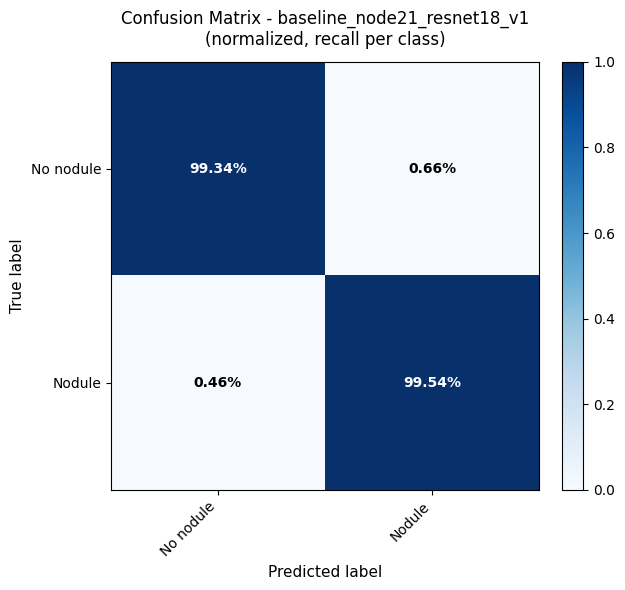


Classification Report
              precision    recall  f1-score   support

   No nodule       1.00      0.99      1.00       761
      Nodule       0.98      1.00      0.99       219

    accuracy                           0.99       980
   macro avg       0.99      0.99      0.99       980
weighted avg       0.99      0.99      0.99       980


CO₂ total      : 0.000965 kg
CO₂ par époque : 0.000965 kg


In [16]:
# ============================================================
# STEP 7 — Runner Baseline (NODE21)
# ============================================================
import os
import numpy as np
import torch

torch.manual_seed(conf.seed)
np.random.seed(conf.seed)

# ── Chemin de sauvegarde ─────────────────────────────────────
SAVE_PATH = "/kaggle/working/baseline/node21"
os.makedirs(SAVE_PATH, exist_ok=True)

# ── Architecture : 'resnet18' | 'resnet50' | 'efficientnet_b0' ──
conf.arch = 'resnet18'
RUN_NAME  = f"baseline_node21_{conf.arch}_v1"

# ── Données ──────────────────────────────────────────────────
factory = DataFactory(conf, dataset="node21")
train_loader, test_loader = factory.loaders()

# ── Modèle + Engine ──────────────────────────────────────────
net    = BaselineNet(conf)
engine = BaselineEngine(
    net, conf, DEVICE,
    run_name=RUN_NAME)

# ── Entraînement (avec tracking CO₂) ─────────────────────────
history = engine.fit(train_loader, test_loader)
engine.summary()

# ── Sauvegardes ──────────────────────────────────────────────
engine.save(f"{SAVE_PATH}/{RUN_NAME}.pt")
engine.save_weights(f"{SAVE_PATH}/{RUN_NAME}_weights.pt")
engine.save_history(f"{SAVE_PATH}/{RUN_NAME}_history.json")
engine.log_experiment(SAVE_PATH)   # ← inclut total_co2_kg, co2_per_epoch_kg, co2_kg

# ── Matrice de confusion sur le test set ─────────────────────
cm = engine.plot_confusion_matrix(
    test_loader,
    class_names=['No nodule', 'Nodule'],
    normalize=True,
    save_path=f"{SAVE_PATH}/{RUN_NAME}_confusion_matrix.png"
)

# ── Affichage CO₂ total ───────────────────────────────────────
emissions = [e for e in engine.history.get("emissions", []) if e is not None]
if emissions:
    print(f"\nCO₂ total      : {sum(emissions):.6f} kg")
    print(f"CO₂ par époque : {sum(emissions)/len(emissions):.6f} kg")
else:
    print("\nCO₂ : non mesuré (codecarbon indisponible)")

# runner ddr

Logger.update patché         ✓
Logger.compute_metric patché ✓  (kappa QWK + f1 macro)
[DDRDataset] split=train |  6260 imgs | C0=3133, C1=315, C2=2238, C3=118, C4=456
[DDRDataset] split=valid |  2503 imgs | C0=1253, C1=126, C2=895, C3=47, C4=182
[Encoder] ImageNet (resnet18)
DataParallel activé : 2 GPUs
BaselineEngine instancié ✓
Architecture : resnet18
Optimizer    : AdamW
Critères     : ['dr_grade']
History keys : ['loss', 'accuracy', 'kappa', 'f1']
Train Epoch: 1
task: dr_grade, loss: 1.47889, accuracy: 0.36054, kappa: 0.21436, f1: 0.23111
avg loss: 1.47889, lr: 0.000010

Test Epoch: 1
task: dr_grade, loss: 0.91148, accuracy: 0.70236, kappa: 0.58005, f1: 0.30236
avg loss: 0.91148

  CO₂ époque 1 : 0.006249 kg

Run          : baseline_ddr_resnet18_v1
Architecture : resnet18
Paramètres   : 11.179 M

── Meilleurs scores (val) ──
  loss         : 0.91148  (époque 1)
  accuracy     : 0.70236  (époque 1)
  kappa        : 0.58005  (époque 1)
  f1           : 0.30236  (époque 1)

── Efficie

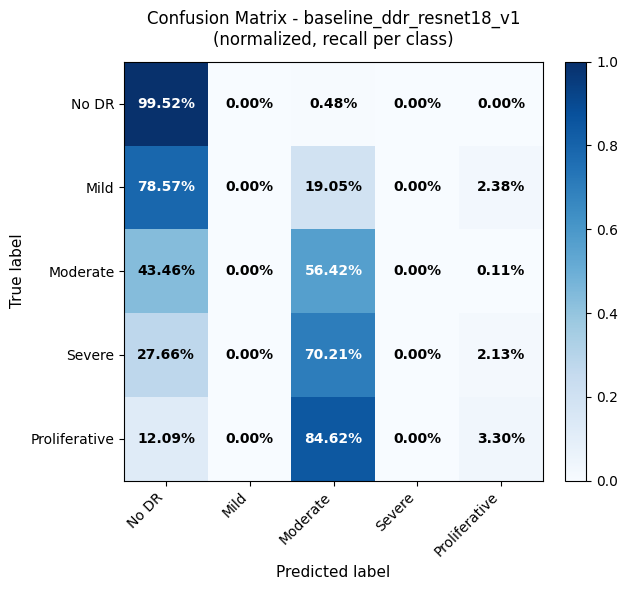


Classification Report
               precision    recall  f1-score   support

        No DR       0.70      1.00      0.83      1253
         Mild       0.00      0.00      0.00       126
     Moderate       0.70      0.56      0.62       895
       Severe       0.00      0.00      0.00        47
Proliferative       0.55      0.03      0.06       182

     accuracy                           0.70      2503
    macro avg       0.39      0.32      0.30      2503
 weighted avg       0.64      0.70      0.64      2503


CO₂ total      : 0.006249 kg
CO₂ par époque : 0.006249 kg


In [17]:
# ============================================================
# STEP 7 — Runner Baseline (DDR)
# ============================================================
import os
import numpy as np
import torch

torch.manual_seed(ddr_conf.seed)
np.random.seed(ddr_conf.seed)

# ── Chemin de sauvegarde ─────────────────────────────────────
SAVE_PATH = "/kaggle/working/baseline/ddr"
os.makedirs(SAVE_PATH, exist_ok=True)

# ── Architecture : 'resnet18' | 'resnet50' | 'efficientnet_b0' ──
ddr_conf.arch = 'resnet18'
RUN_NAME      = f"baseline_ddr_{ddr_conf.arch}_v1"

# ── Enregistrement DDR dans DataFactory ──────────────────────
DataFactory._registry["ddr"] = DDRDataset

# ── Patch Logger (kappa QWK + f1 macro) ──────────────────────
from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score

def _patched_update(self, next_loss, next_y_pred, next_y_true):
    for task in self.task_dict.values():
        t = task['name']
        self.losses_it[t].append(next_loss[t])
        raw = next_y_pred[t]
        if isinstance(raw, np.ndarray):
            self.y_preds[t].extend(raw.tolist())
        else:
            self.y_preds[t].extend(raw)
        if isinstance(next_y_true[t], np.ndarray):
            self.y_trues[t].extend(next_y_true[t].tolist())
        else:
            self.y_trues[t].extend(
                next_y_true[t] if hasattr(next_y_true[t], '__iter__')
                else [next_y_true[t]])

def _patched_compute_metric(self):
    for task in self.task_dict.values():
        t      = task['name']
        losses = self.losses_it[t]
        self.losses_epoch[t].append(np.mean(losses))

        requested = task['metric']
        if isinstance(requested, str):
            requested = [requested]

        y_true     = np.array(self.y_trues[t])
        y_pred_raw = np.array(self.y_preds[t])

        epoch_metrics = {}
        for current_metric in requested:

            if current_metric == 'accuracy':
                y_pred = np.argmax(y_pred_raw, axis=-1) \
                         if y_pred_raw.ndim == 2 \
                         else (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = accuracy_score(y_true, y_pred)

            elif current_metric == 'kappa':
                y_pred = np.argmax(y_pred_raw, axis=-1) \
                         if y_pred_raw.ndim == 2 \
                         else (y_pred_raw >= 0.5).astype(int)
                try:
                    epoch_metrics[current_metric] = cohen_kappa_score(
                        y_true, y_pred, weights='quadratic')
                except Exception:
                    epoch_metrics[current_metric] = 0.0

            elif current_metric == 'f1':
                y_pred = np.argmax(y_pred_raw, axis=-1) \
                         if y_pred_raw.ndim == 2 \
                         else (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = f1_score(
                    y_true, y_pred, average='macro', zero_division=0)

        self.metrics[t].append(epoch_metrics)
        self.losses_it[t] = []
        self.y_preds[t]   = []
        self.y_trues[t]   = []

Logger.update         = _patched_update
Logger.compute_metric = _patched_compute_metric
print("Logger.update patché         ✓")
print("Logger.compute_metric patché ✓  (kappa QWK + f1 macro)")

# ── Seeds ────────────────────────────────────────────────────
torch.manual_seed(ddr_conf.seed)
np.random.seed(ddr_conf.seed)

# ── Données ──────────────────────────────────────────────────
factory = DataFactory(ddr_conf, dataset="ddr")
train_loader, val_loader = factory.loaders()

# ── Modèle + Engine ──────────────────────────────────────────
net    = BaselineNet(ddr_conf)
engine = BaselineEngine(
    net, ddr_conf, DEVICE,
    run_name=RUN_NAME)

# ── Entraînement (avec tracking CO₂) ─────────────────────────
history = engine.fit(train_loader, val_loader)
engine.summary()

# ── Sauvegardes ──────────────────────────────────────────────
engine.save(f"{SAVE_PATH}/{RUN_NAME}.pt")
engine.save_weights(f"{SAVE_PATH}/{RUN_NAME}_weights.pt")
engine.save_history(f"{SAVE_PATH}/{RUN_NAME}_history.json")
engine.log_experiment(SAVE_PATH)   # ← inclut total_co2_kg, co2_per_epoch_kg, co2_kg

# ── Matrice de confusion sur le val set ──────────────────────
cm = engine.plot_confusion_matrix(
    val_loader,
    class_names=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'],
    normalize=True,
    save_path=f"{SAVE_PATH}/{RUN_NAME}_confusion_matrix.png"
)

# ── Affichage CO₂ total ───────────────────────────────────────
emissions = [e for e in engine.history.get("emissions", []) if e is not None]
if emissions:
    print(f"\nCO₂ total      : {sum(emissions):.6f} kg")
    print(f"CO₂ par époque : {sum(emissions)/len(emissions):.6f} kg")
else:
    print("\nCO₂ : non mesuré (codecarbon indisponible)")

# Registration + WeightedSampler + Runner.

Logger restauré (original) ✓  (auc / precision / recall actifs)
Train : 20005 images | pos=4509 (22.5%) | neg=15496 (77.5%) | ratio=3.44:1
Test  : 6679 images | pos=1503 (22.5%) | neg=5176 (77.5%) | ratio=3.44:1

WeightedSampler :
  n_pos=4509, n_neg=15496, ratio=3.44:1
  w_pos=0.000222, w_neg=0.000065

DataLoaders :
  train batches : 1251
  test  batches : 418
[Encoder] ImageNet (resnet18)
DataParallel activé : 2 GPUs
BaselineEngine instancié ✓
Architecture : resnet18
Optimizer    : AdamW
Critères     : ['pneumonia']
History keys : ['loss', 'accuracy', 'auc', 'f1', 'precision', 'recall']
Train Epoch: 1
task: pneumonia, loss: 0.53814, accuracy: 0.72647, auc: 0.80361, f1: 0.73232, precision: 0.71272, recall: 0.75302
avg loss: 0.53814, lr: 0.000010

Test Epoch: 1
task: pneumonia, loss: 0.48539, accuracy: 0.75700, auc: 0.84149, f1: 0.58395, precision: 0.47498, recall: 0.75782
avg loss: 0.48539

  CO₂ époque 1 : 0.001037 kg

Run          : baseline_rsna_resnet18_v1
Architecture : resnet18


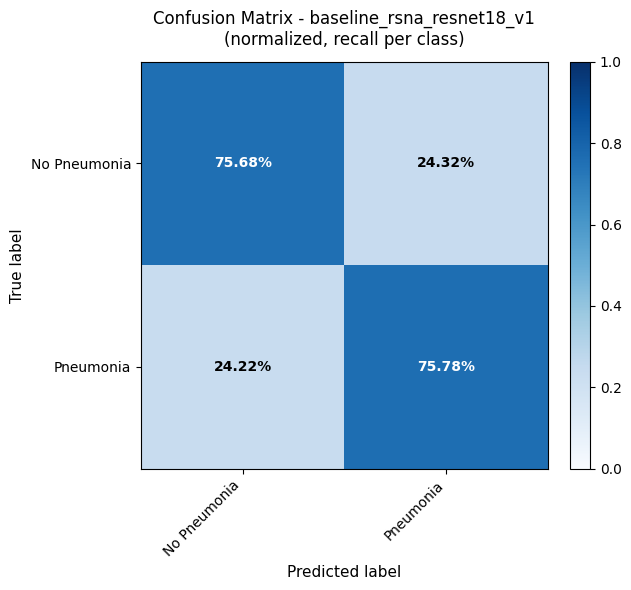


Classification Report
              precision    recall  f1-score   support

No Pneumonia       0.91      0.76      0.83      5176
   Pneumonia       0.47      0.76      0.58      1503

    accuracy                           0.76      6679
   macro avg       0.69      0.76      0.71      6679
weighted avg       0.82      0.76      0.77      6679


CO₂ total      : 0.001037 kg
CO₂ par époque : 0.001037 kg


In [20]:
# ============================================================
# STEP 7 — Runner Baseline (RSNA)
# ============================================================
import os
import numpy as np
import torch
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              f1_score, precision_score, recall_score)

# ── Restauration du Logger original (écrase le patch DDR) ────
def _original_update(self, next_loss, next_y_pred, next_y_true):
    for task in self.task_dict.values():
        t      = task['name']
        t_metr = task['metric']
        if isinstance(t_metr, str):
            t_metr = [t_metr]

        self.losses_it[t].append(next_loss[t])

        has_auc_f1 = any(m in ['auc', 'f1', 'precision', 'recall']
                         for m in t_metr)

        if t_metr == ['accuracy']:
            y_pred = np.argmax(next_y_pred[t], axis=-1)
        elif has_auc_f1:
            raw = next_y_pred[t]
            if raw.ndim == 2:
                y_pred = raw[:, 1].tolist()
            else:
                y_pred = raw.tolist()
        else:
            y_pred = next_y_pred[t].tolist()

        self.y_preds[t].extend(y_pred)
        self.y_trues[t].extend(next_y_true[t])

def _original_compute_metric(self):
    for task in self.task_dict.values():
        t      = task['name']
        losses = self.losses_it[t]
        self.losses_epoch[t].append(np.mean(losses))

        requested = task['metric']
        if isinstance(requested, str):
            requested = [requested]

        y_true     = np.array(self.y_trues[t])
        y_pred_raw = np.array(self.y_preds[t])

        epoch_metrics = {}
        for current_metric in requested:

            if current_metric == 'accuracy':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = accuracy_score(y_true, y_pred)

            elif current_metric == 'auc':
                scores = (y_pred_raw[:, 1]
                          if y_pred_raw.ndim == 2 else y_pred_raw)
                epoch_metrics[current_metric] = roc_auc_score(y_true, scores)

            elif current_metric == 'f1':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = f1_score(
                    y_true, y_pred, zero_division=0)

            elif current_metric == 'precision':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = precision_score(
                    y_true, y_pred, zero_division=0)

            elif current_metric == 'recall':
                if y_pred_raw.ndim == 2:
                    y_pred = np.argmax(y_pred_raw, axis=-1)
                else:
                    y_pred = (y_pred_raw >= 0.5).astype(int)
                epoch_metrics[current_metric] = recall_score(
                    y_true, y_pred, zero_division=0)

        self.metrics[t].append(epoch_metrics)

        # Réinitialisation
        self.losses_it[t] = []
        self.y_preds[t]   = []
        self.y_trues[t]   = []

Logger.update         = _original_update
Logger.compute_metric = _original_compute_metric
print("Logger restauré (original) ✓  (auc / precision / recall actifs)")

# ── Chemin de sauvegarde ─────────────────────────────────────
SAVE_PATH = "/kaggle/working/baseline/rsna"
os.makedirs(SAVE_PATH, exist_ok=True)

# ── Architecture : 'resnet18' | 'resnet50' | 'efficientnet_b0' ──
rsna_baseline_conf.arch = 'resnet18'
RUN_NAME                = f"baseline_rsna_{rsna_baseline_conf.arch}_v1"

# ── Enregistrement RSNA dans DataFactory ─────────────────────
DataFactory._registry["rsna_baseline"] = RSNADatasetBaseline

# ── Seeds ────────────────────────────────────────────────────
torch.manual_seed(rsna_baseline_conf.seed)
np.random.seed(rsna_baseline_conf.seed)

# ── Données ──────────────────────────────────────────────────
ds_train_bl = RSNADatasetBaseline(rsna_baseline_conf, train=True)
ds_test_bl  = RSNADatasetBaseline(rsna_baseline_conf, train=False)

# ── WeightedRandomSampler (déséquilibre ~3.44:1) ─────────────
from torch.utils.data import DataLoader, WeightedRandomSampler

labels_train_bl = np.array([ds_train_bl[i]['pneumonia']
                             for i in range(len(ds_train_bl))])

n_pos_bl   = labels_train_bl.sum()
n_neg_bl   = len(labels_train_bl) - n_pos_bl
w_pos_bl   = 1.0 / n_pos_bl
w_neg_bl   = 1.0 / n_neg_bl
weights_bl = np.where(labels_train_bl == 1, w_pos_bl, w_neg_bl)

sampler_bl = WeightedRandomSampler(
    weights     = torch.from_numpy(weights_bl).float(),
    num_samples = len(weights_bl),
    replacement = True
)

print(f"\nWeightedSampler :")
print(f"  n_pos={n_pos_bl}, n_neg={n_neg_bl}, "
      f"ratio={n_neg_bl/n_pos_bl:.2f}:1")
print(f"  w_pos={w_pos_bl:.6f}, w_neg={w_neg_bl:.6f}")

train_loader_bl = DataLoader(
    ds_train_bl,
    batch_size         = rsna_baseline_conf.B,
    sampler            = sampler_bl,
    num_workers        = rsna_baseline_conf.n_worker,
    pin_memory         = rsna_baseline_conf.pin_memory,
    persistent_workers = True
)

test_loader_bl = DataLoader(
    ds_test_bl,
    batch_size         = rsna_baseline_conf.B,
    shuffle            = False,
    num_workers        = rsna_baseline_conf.n_worker,
    pin_memory         = rsna_baseline_conf.pin_memory,
    persistent_workers = True
)

print(f"\nDataLoaders :")
print(f"  train batches : {len(train_loader_bl)}")
print(f"  test  batches : {len(test_loader_bl)}")

# ── Modèle + Engine ──────────────────────────────────────────
net_bl    = BaselineNet(rsna_baseline_conf)
engine_bl = BaselineEngine(
    net_bl, rsna_baseline_conf, DEVICE,
    run_name=RUN_NAME)

# ── Entraînement (avec tracking CO₂) ─────────────────────────
history_bl = engine_bl.fit(train_loader_bl, test_loader_bl)
engine_bl.summary()

# ── Sauvegardes ──────────────────────────────────────────────
engine_bl.save(f"{SAVE_PATH}/{RUN_NAME}.pt")
engine_bl.save_weights(f"{SAVE_PATH}/{RUN_NAME}_weights.pt")
engine_bl.save_history(f"{SAVE_PATH}/{RUN_NAME}_history.json")
engine_bl.log_experiment(SAVE_PATH)

# ── Matrice de confusion sur le test set ─────────────────────
cm = engine_bl.plot_confusion_matrix(
    test_loader_bl,
    class_names=['No Pneumonia', 'Pneumonia'],
    normalize=True,
    save_path=f"{SAVE_PATH}/{RUN_NAME}_confusion_matrix.png"
)

# ── Affichage CO₂ total ───────────────────────────────────────
emissions = [e for e in engine_bl.history.get("emissions", []) if e is not None]
if emissions:
    print(f"\nCO₂ total      : {sum(emissions):.6f} kg")
    print(f"CO₂ par époque : {sum(emissions)/len(emissions):.6f} kg")
else:
    print("\nCO₂ : non mesuré (codecarbon indisponible)")